In [2]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [3]:
#Importing Dataset
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#Exploring Dataset 
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
print(df.shape)


(768, 9)


In [6]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().T 
#''' Some features have zeros which is not possible so will have to impute them '''

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [8]:
#Checking for columns with zero values
print('Missing Values')
print('Glucose:',df[df['Glucose']==0].shape[0])
print('Blood Pressure:',df[df['BloodPressure']==0].shape[0])
print('Skin Thickness:',df[df['SkinThickness']==0].shape[0])
print('Insulin:',df[df['Insulin']==0].shape[0])
print('BMI:',df[df['BMI']==0].shape[0])

Missing Values
Glucose: 5
Blood Pressure: 35
Skin Thickness: 227
Insulin: 374
BMI: 11


# Feature Disttibution Visualization #

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

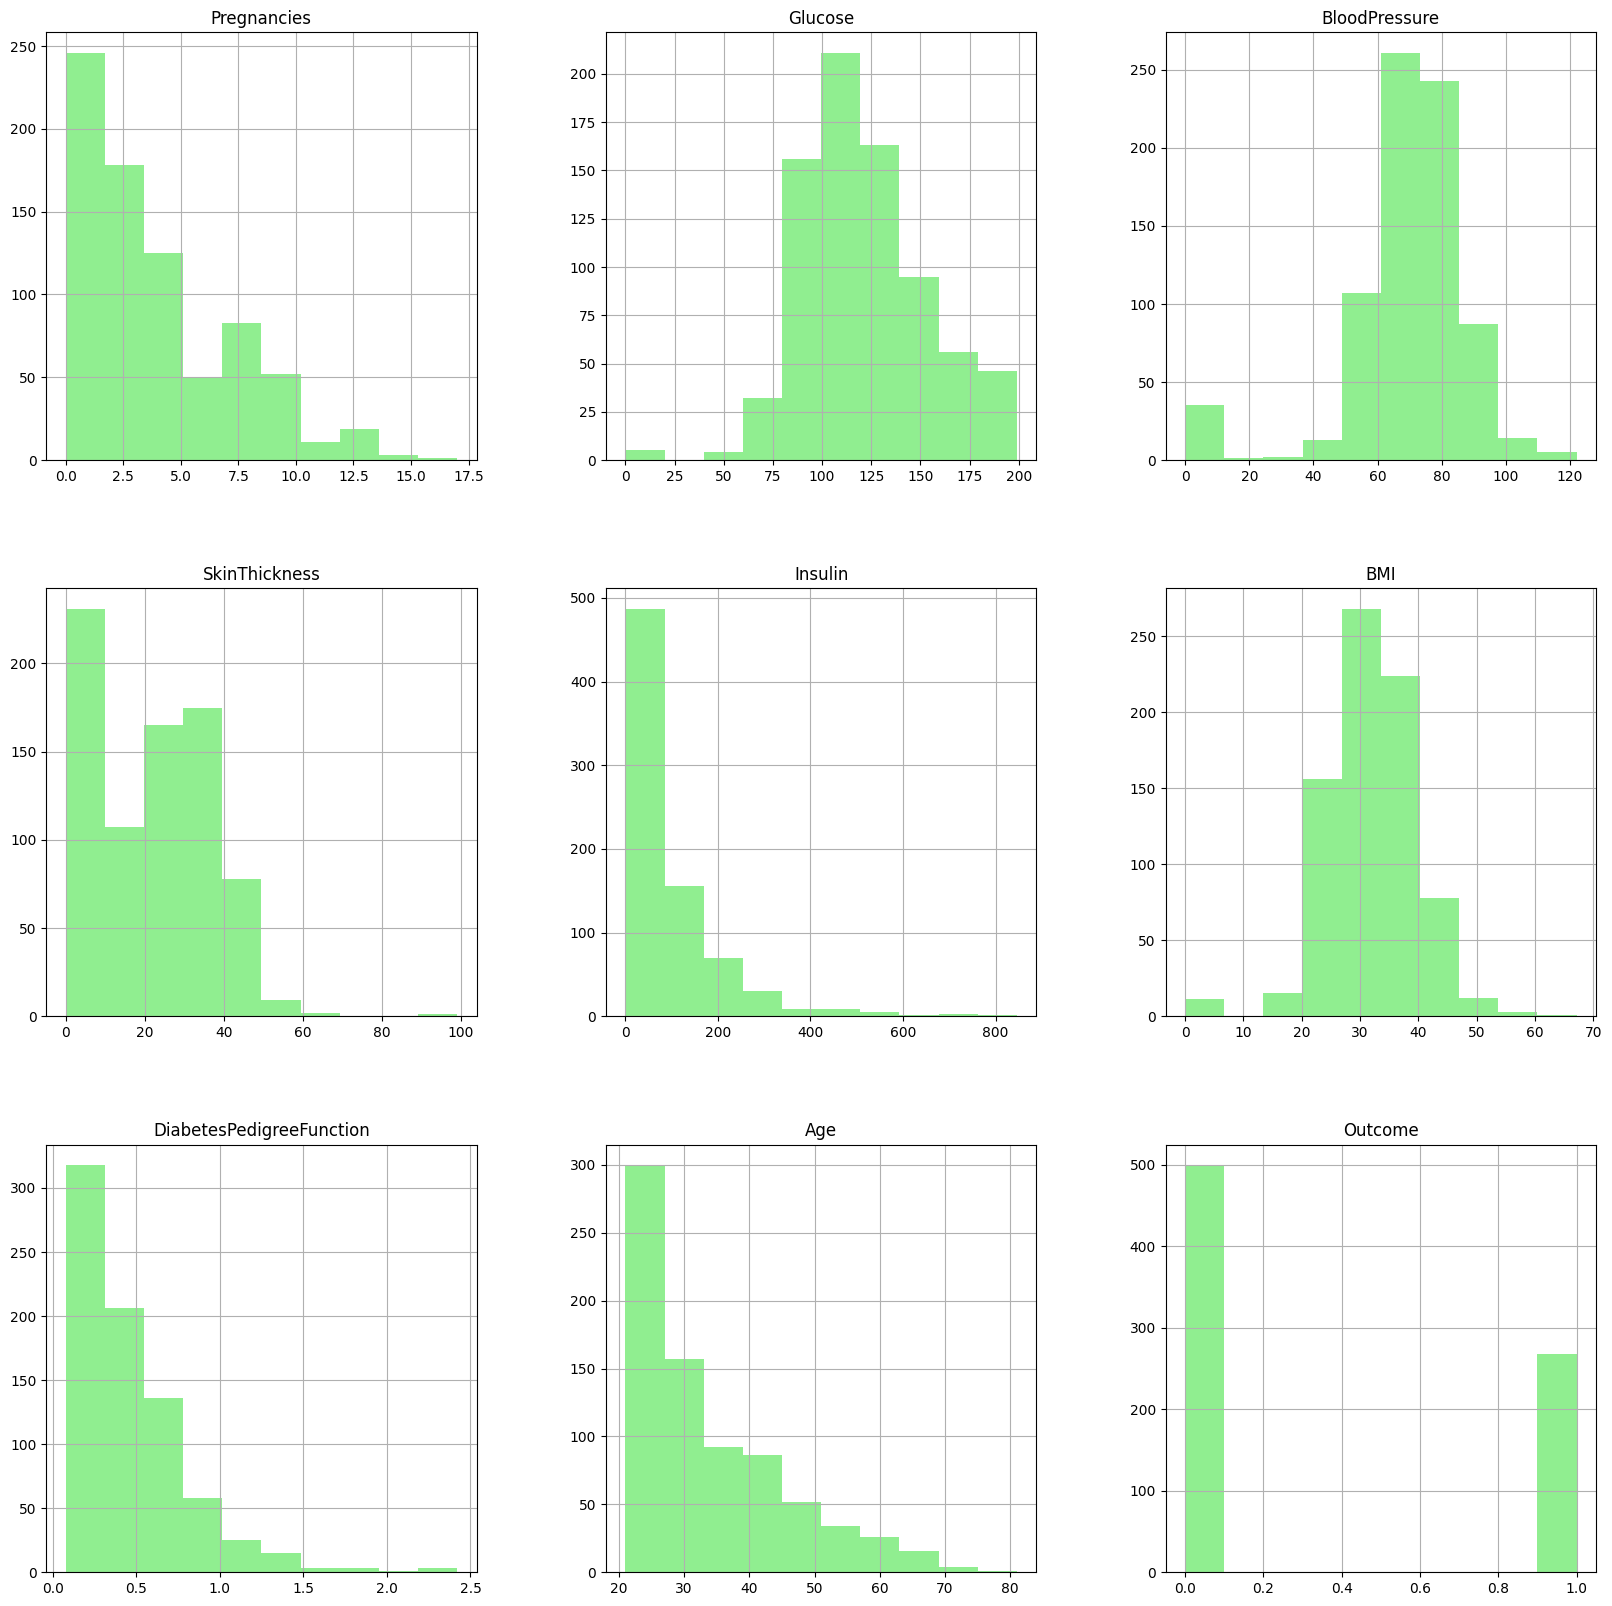

In [9]:
df.hist(color = 'lightgreen', figsize = (20,20))

In [10]:
# Handling Zero Values

df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['SkinThickness'] =  df['SkinThickness'].replace(0, df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())

<Axes: ylabel='Outcome'>

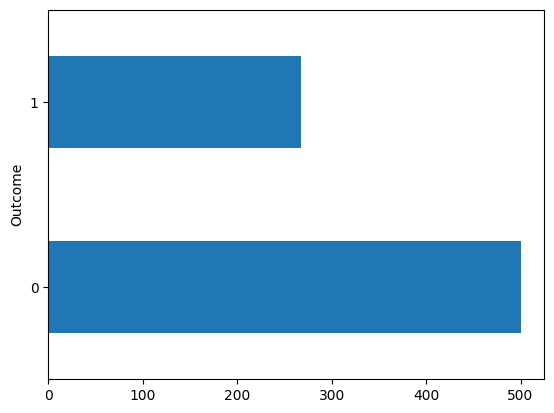

In [11]:
#Class Distribution of Outcome
df['Outcome'].value_counts().plot(kind = 'barh')

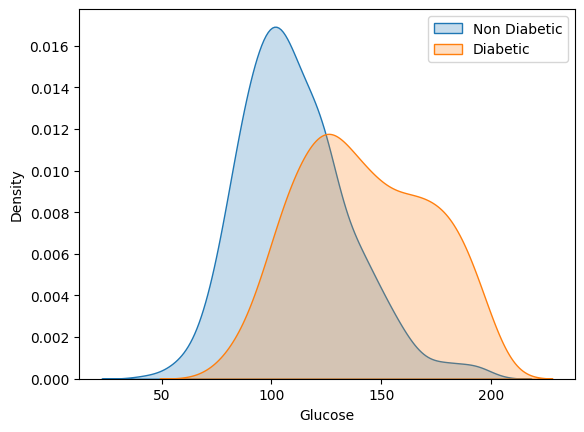

In [12]:
#KDE plot for blood sugar levels
sns.kdeplot(df[df['Outcome']==0]['Glucose'], label='Non Diabetic', fill=True)
sns.kdeplot(df[df['Outcome']==1]['Glucose'], label='Diabetic', fill=True)
plt.legend()
plt.show()

<Axes: >

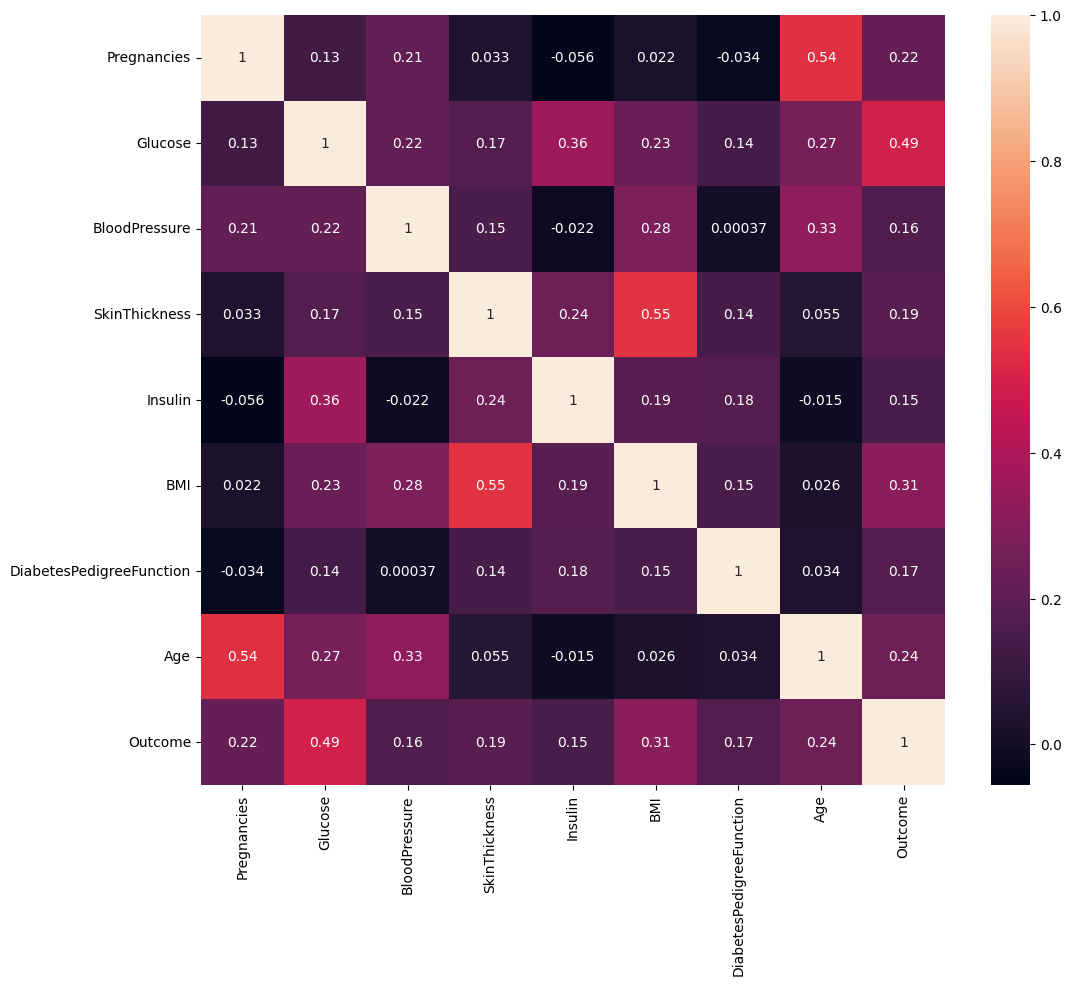

In [13]:
#Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True)

# Feature Scaling with Standard Scaler

In [15]:
ss = StandardScaler()
X = pd.DataFrame(ss.fit_transform(df.drop(columns=['Outcome'])), columns=df.columns[:-1])

In [16]:
y = df['Outcome']

# Splitting Data into Train & Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

#Predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

#Accuracy Score
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Set Accuracy:", train_acc)
print("Test Set Accuracy:", test_acc)

#Confusion Matrix
print("Confusion maatrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))



Train Set Accuracy: 0.7947882736156352
Test Set Accuracy: 0.7077922077922078
Confusion maatrix:
 [[82 18]
 [27 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(X_train, y_train)

#Predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

#Accuracy Score
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Set Accuracy:", train_acc *100)
print("Test Set Accuracy:", test_acc*100)

#Confusion Matrix
print("Confusion maatrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))



Train Set Accuracy: 76.54723127035831
Test Set Accuracy: 72.72727272727273
Confusion maatrix:
 [[74 26]
 [16 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



# Random Forest Model with Hyperparameter Tuning

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

#hyperparameter grid
param_rf = {
    'n_estimators':[50, 100, 200, 300],
    'max_depth': [10,20,30],
    'min_samples_leaf': [2,5,10]
}

#Perform Grid search with cross-validation
rf = RandomForestClassifier()
grid = GridSearchCV(estimator =rf, param_grid = param_rf, cv= 5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get best Model
print("Best Parameters:", grid.best_params_)
rfc = grid.best_estimator_

#Predictions
y_train_pred= rfc.predict(X_train)
y_test_pred=rfc.predict(X_test)

#Accuracy Scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Set Accuracy:", train_acc*100)
print("Test Set Accuracy:", test_acc*100)

#Classification Report
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Train Set Accuracy: 89.73941368078175
Test Set Accuracy: 73.37662337662337
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



In [35]:
#Better Tuning the model with hyperparameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

#hyperparameter grid
param_rf = {
    'n_estimators':[50, 100, 200, 300],
    'max_depth': [3,5,7],
    'min_samples_leaf': [2,5,10]
}

#Perform Grid search with cross-validation
rf = RandomForestClassifier(class_weight='balanced')
grid = GridSearchCV(estimator =rf, param_grid = param_rf, cv= 5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get best Model
print("Best Parameters:", grid.best_params_)
rfc = grid.best_estimator_

#Predictions
y_train_pred= rfc.predict(X_train)
y_test_pred=rfc.predict(X_test)

#Accuracy Scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Set Accuracy:", train_acc*100)
print("Test Set Accuracy:", test_acc*100)

#Classification Report
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 300}
Train Set Accuracy: 90.39087947882736
Test Set Accuracy: 75.97402597402598
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81       100
           1       0.63      0.74      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.77      0.76      0.76       154



# SHAP values for Feature Importance

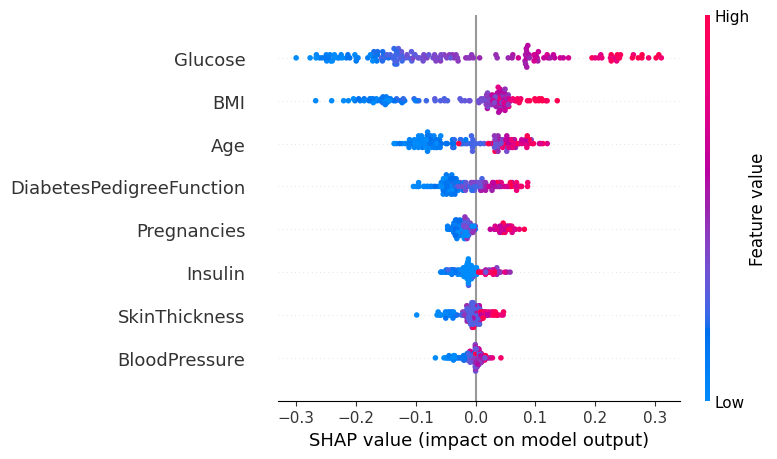

In [40]:
import shap

explainer = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)


# Saving Model & Scaler with Pickle

In [42]:
import pickle
pickle.dump(rfc, open('model.pkl', 'wb'))
pickle.dump(ss, open('scaler.pkl', 'wb'))